# Customer Churn Prediction — IBM Telco Dataset

**Author:** Ahmed Asef Daiyan Chowdhury  
**Programme:** MSc Computer Science & Technology (ML/AI), Ulster University  

---

## Business Problem
Customer churn — when subscribers cancel their service — is one of the costliest challenges in the telecom industry. Acquiring a new customer costs 5–25× more than retaining an existing one. This project builds a machine-learning pipeline that:
1. Identifies the key drivers of churn using exploratory analysis.
2. Trains predictive models (Logistic Regression & Random Forest) to flag at-risk customers.
3. Surfaces actionable retention strategies for the business.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features.

---
## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from data_loader import load_data, get_overview, clean_data, encode_features
from model_utils import evaluate_model, plot_confusion_matrix, plot_feature_importance

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

DATA_PATH = "../data/Telco-Customer-Churn.csv"

print("All imports successful.")

All imports successful.


---
## 2. Data Loading & Overview

In [2]:
df_raw = load_data(DATA_PATH)

print("=" * 55)
print("  Dataset Overview")
print("=" * 55)
get_overview(df_raw)
print("\nFirst 5 rows:")
df_raw.head()

  Dataset Overview
Shape: 7043 rows × 21 columns

Column dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

Missing values per column:
  None

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Value counts for target variable
print("Churn distribution (raw counts):")
print(df_raw["Churn"].value_counts())
print(f"\nChurn rate: {df_raw['Churn'].value_counts(normalize=True)['Yes']:.2%}")

Churn distribution (raw counts):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


---
## 3. Data Cleaning

In [4]:
df = clean_data(df_raw)

print(f"Cleaned dataset shape: {df.shape}")
print(f"\nData types after cleaning:")
print(df.dtypes.to_string())
print(f"\nRemaining nulls: {df.isnull().sum().sum()}")
df.head()

[clean_data] Imputed 11 missing TotalCharges with median (1397.47)
Cleaned dataset shape: (7043, 20)

Data types after cleaning:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64

Remaining nulls: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
# Basic descriptive statistics for numeric columns
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


---
## 4. Exploratory Data Analysis

All figures are saved to `outputs/figures/`.

### 4.1 Churn Rate — Pie Chart

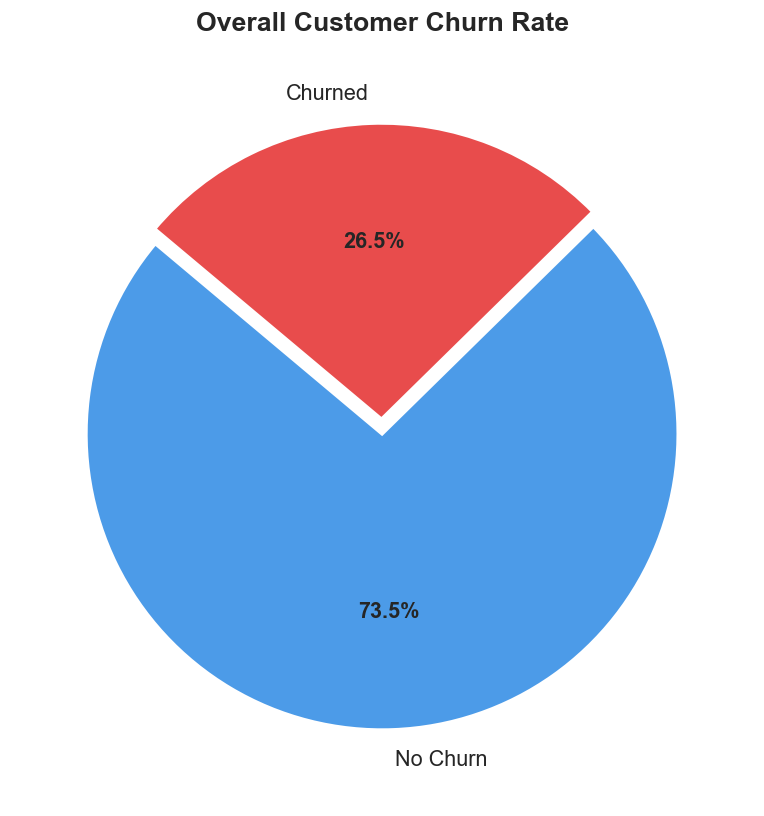

[saved] 01_churn_rate_pie.png


In [6]:
churn_counts = df["Churn"].value_counts()
labels = ["No Churn", "Churned"]
colors = ["#4C9BE8", "#E84C4C"]
explode = (0, 0.05)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 13},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
ax.set_title("Overall Customer Churn Rate", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_churn_rate_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 01_churn_rate_pie.png")

### 4.2 Churn by Contract Type — Bar Chart

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4728\9912880.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


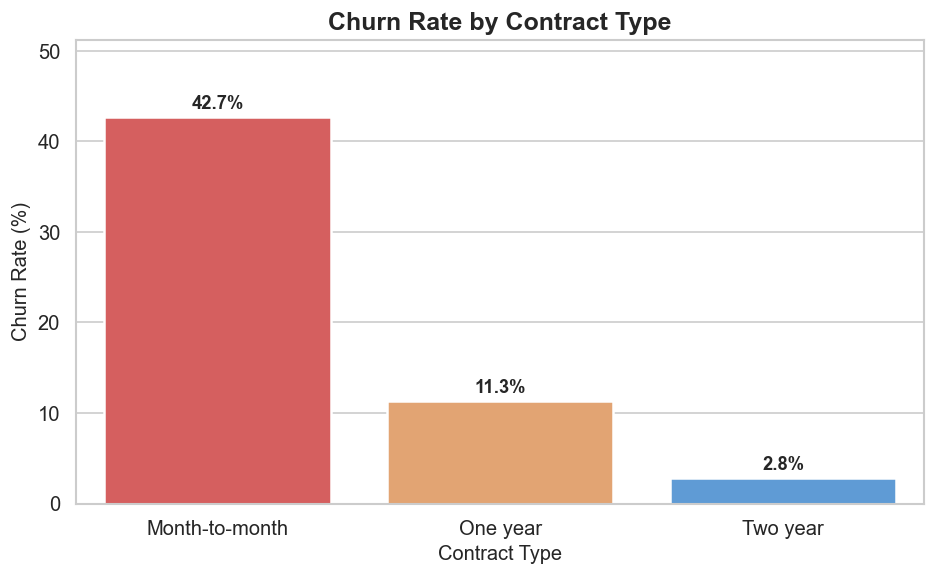

[saved] 02_churn_by_contract.png


In [7]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"Churn": "Churn Rate (%)"})
    .sort_values("Churn Rate (%)", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(
    data=contract_churn,
    x="Contract", y="Churn Rate (%)",
    palette=["#E84C4C", "#F4A261", "#4C9BE8"],
    edgecolor="white", linewidth=1.5,
    ax=ax,
)
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_title("Churn Rate by Contract Type", fontsize=15, fontweight="bold")
ax.set_xlabel("Contract Type", fontsize=12)
ax.set_ylabel("Churn Rate (%)", fontsize=12)
ax.set_ylim(0, contract_churn["Churn Rate (%)"].max() * 1.2)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 02_churn_by_contract.png")

### 4.3 Churn by Tenure — Histogram

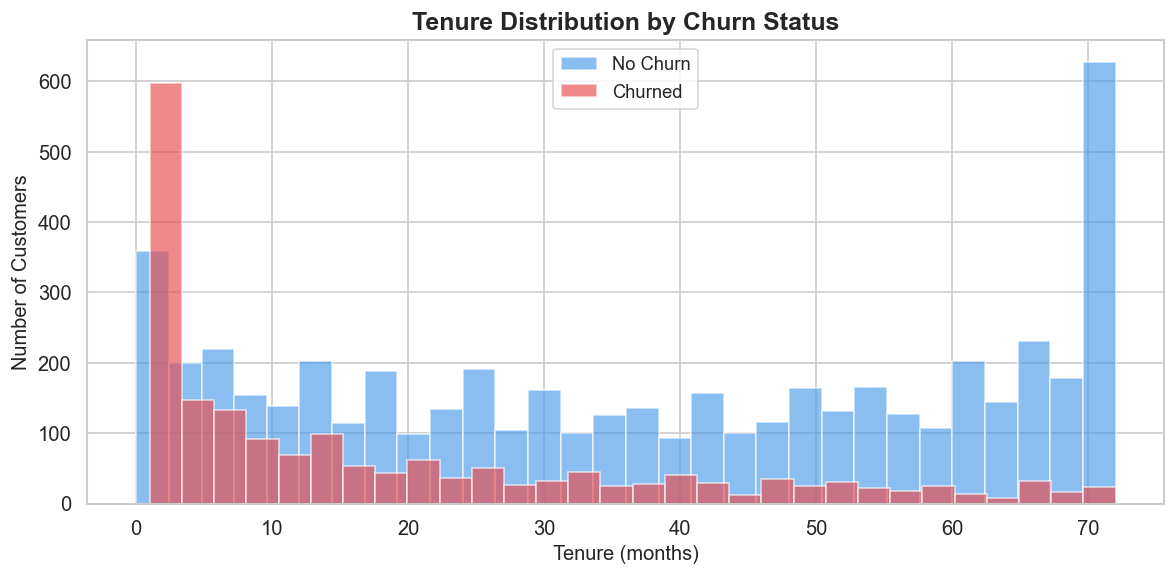

[saved] 03_churn_by_tenure.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

df_no_churn  = df[df["Churn"] == 0]["tenure"]
df_yes_churn = df[df["Churn"] == 1]["tenure"]

ax.hist(df_no_churn,  bins=30, alpha=0.65, color="#4C9BE8", label="No Churn",  edgecolor="white")
ax.hist(df_yes_churn, bins=30, alpha=0.65, color="#E84C4C", label="Churned",   edgecolor="white")

ax.set_title("Tenure Distribution by Churn Status", fontsize=15, fontweight="bold")
ax.set_xlabel("Tenure (months)", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 03_churn_by_tenure.png")

### 4.4 Monthly Charges Distribution by Churn — Boxplot

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4728\3127013548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


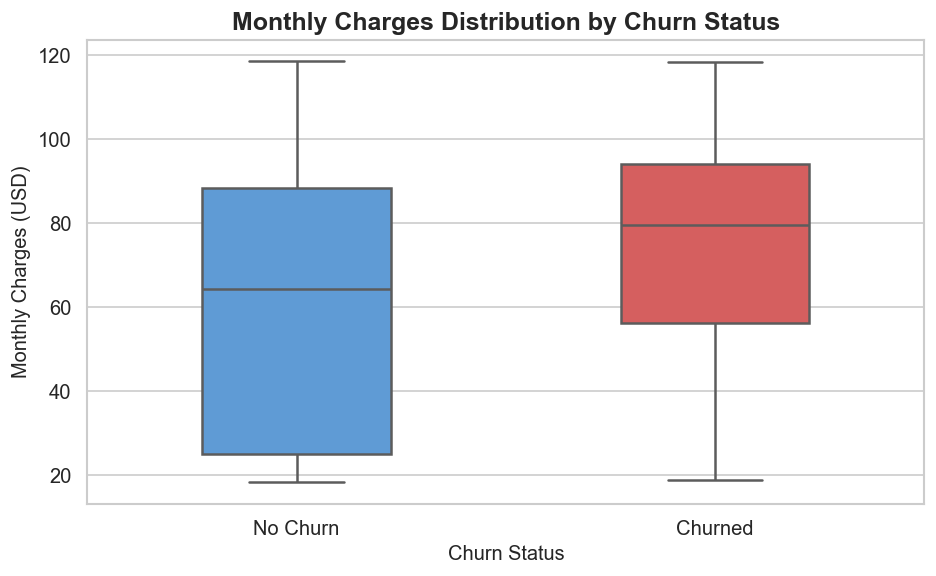

[saved] 04_monthly_charges_boxplot.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df_plot = df.copy()
df_plot["Churn Label"] = df_plot["Churn"].map({0: "No Churn", 1: "Churned"})

sns.boxplot(
    data=df_plot,
    x="Churn Label", y="MonthlyCharges",
    palette={"No Churn": "#4C9BE8", "Churned": "#E84C4C"},
    width=0.45, linewidth=1.5, flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    ax=ax,
)
ax.set_title("Monthly Charges Distribution by Churn Status", fontsize=15, fontweight="bold")
ax.set_xlabel("Churn Status", fontsize=12)
ax.set_ylabel("Monthly Charges (USD)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_monthly_charges_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 04_monthly_charges_boxplot.png")

### 4.5 Correlation Heatmap

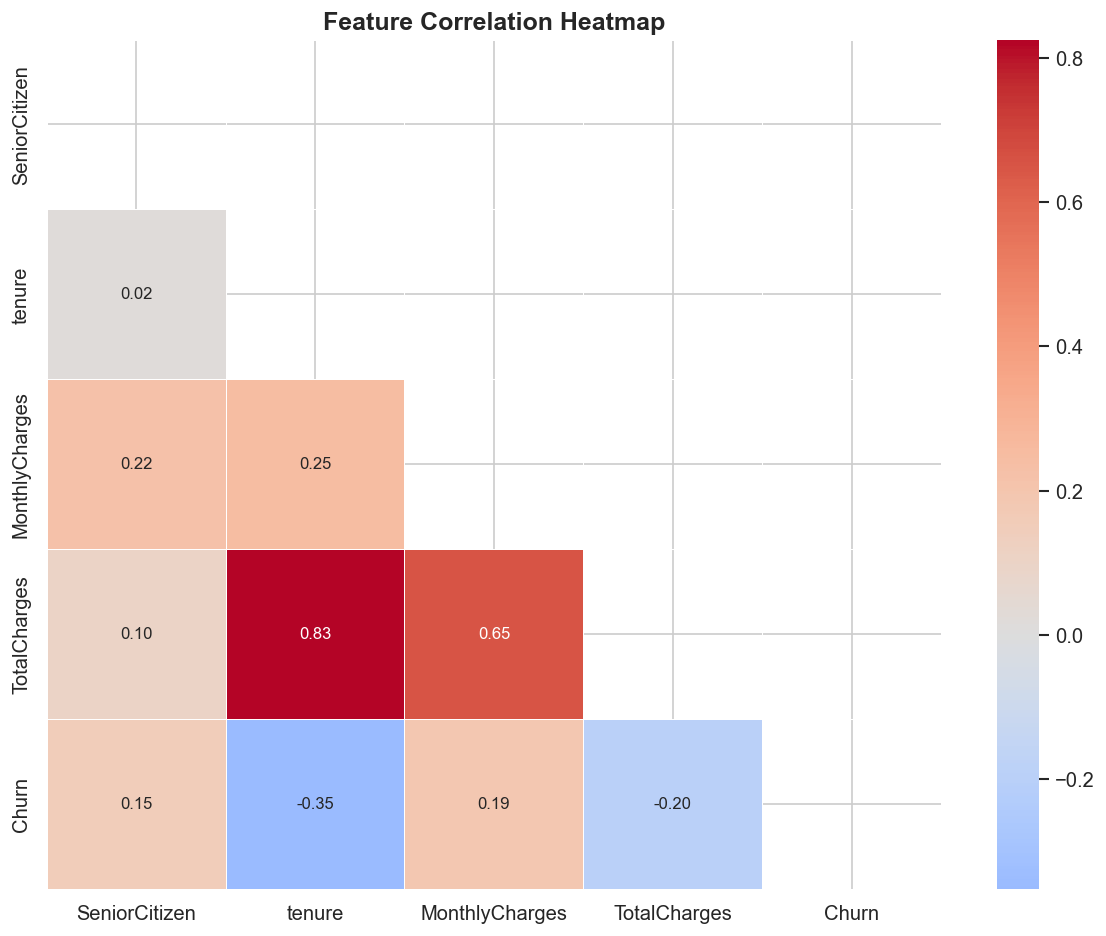

[saved] 05_correlation_heatmap.png


In [10]:
# Select numeric columns only for correlation
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title("Feature Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 05_correlation_heatmap.png")

### 4.6 Churn by Internet Service Type — Bar Chart

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4728\3040864102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


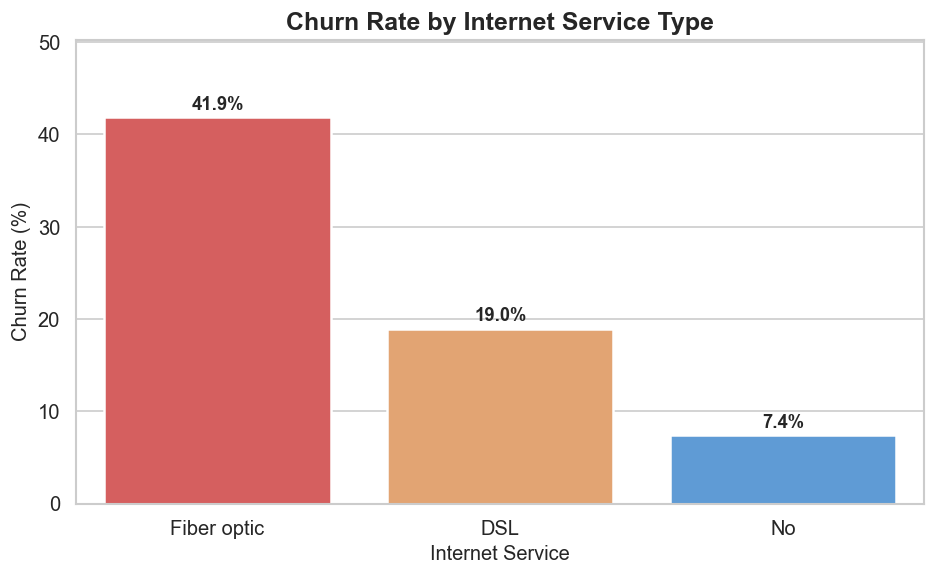

[saved] 06_churn_by_internet_service.png


In [11]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"Churn": "Churn Rate (%)"})
    .sort_values("Churn Rate (%)", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=internet_churn,
    x="InternetService", y="Churn Rate (%)",
    palette=["#E84C4C", "#F4A261", "#4C9BE8"],
    edgecolor="white", linewidth=1.5,
    ax=ax,
)
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4),
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_title("Churn Rate by Internet Service Type", fontsize=15, fontweight="bold")
ax.set_xlabel("Internet Service", fontsize=12)
ax.set_ylabel("Churn Rate (%)", fontsize=12)
ax.set_ylim(0, internet_churn["Churn Rate (%)"].max() * 1.2)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_churn_by_internet_service.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] 06_churn_by_internet_service.png")

---
## 5. Feature Engineering

In [12]:
df_encoded = encode_features(df)

print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"Number of features: {df_encoded.shape[1] - 1}")
print(f"\nColumn list:")
print(df_encoded.columns.tolist())

Encoded dataset shape: (7043, 31)
Number of features: 30

Column list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Train / test split — 80 / 20, stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Churn rate (train): {y_train.mean():.2%}")
print(f"Churn rate (test) : {y_test.mean():.2%}")

Training set : 5634 rows
Test set     : 1409 rows
Churn rate (train): 26.54%
Churn rate (test) : 26.54%


In [14]:
# Scale numerical features — fit on train, transform both splits
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler   = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Numerical features scaled (StandardScaler).")

Numerical features scaled (StandardScaler).


---
## 6. Model Training

### 6.1 Logistic Regression

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # accounts for class imbalance (~26% churn)
    random_state=42,
)
lr_model.fit(X_train, y_train)
print("Logistic Regression — training complete.")

Logistic Regression — training complete.


### 6.2 Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print("Random Forest — training complete.")

Random Forest — training complete.


---
## 7. Model Evaluation

In [17]:
lr_metrics = evaluate_model(lr_model, X_test, y_test, model_name="Logistic Regression")


  Logistic Regression — Evaluation Results
  Accuracy : 0.7388
  Precision: 0.5052
  Recall   : 0.7834
  F1 Score : 0.6143

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [18]:
rf_metrics = evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")


  Random Forest — Evaluation Results
  Accuracy : 0.7722
  Precision: 0.5582
  Recall   : 0.6791
  F1 Score : 0.6128

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409



In [19]:
# Side-by-side metrics comparison
comparison = pd.DataFrame(
    {"Logistic Regression": lr_metrics, "Random Forest": rf_metrics}
).T.round(4)
print("\nModel Comparison:")
comparison


Model Comparison:


,accuracy,precision,recall,f1
Logistic Regression,0.7388,0.5052,0.7834,0.6143
Random Forest,0.7722,0.5582,0.6791,0.6128


[saved] ../outputs/figures/07_confusion_matrix_lr.png

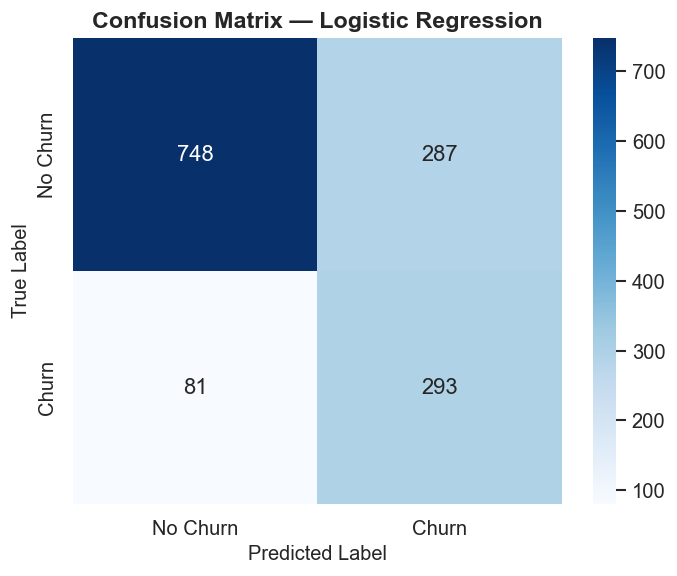

In [20]:
# Confusion matrix — Logistic Regression
plot_confusion_matrix(
    lr_model, X_test, y_test,
    model_name="Logistic Regression",
    save_path=f"{FIGURES_DIR}/07_confusion_matrix_lr.png",
)

[saved] ../outputs/figures/08_confusion_matrix_rf.png


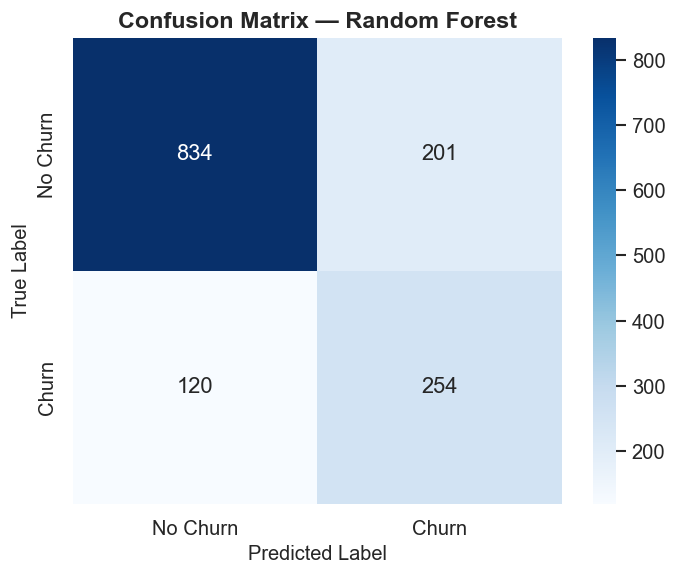

In [21]:
# Confusion matrix — Random Forest
plot_confusion_matrix(
    rf_model, X_test, y_test,
    model_name="Random Forest",
    save_path=f"{FIGURES_DIR}/08_confusion_matrix_rf.png",
)

---
## 8. Feature Importance

[saved] ../outputs/figures/09_feature_importance.png


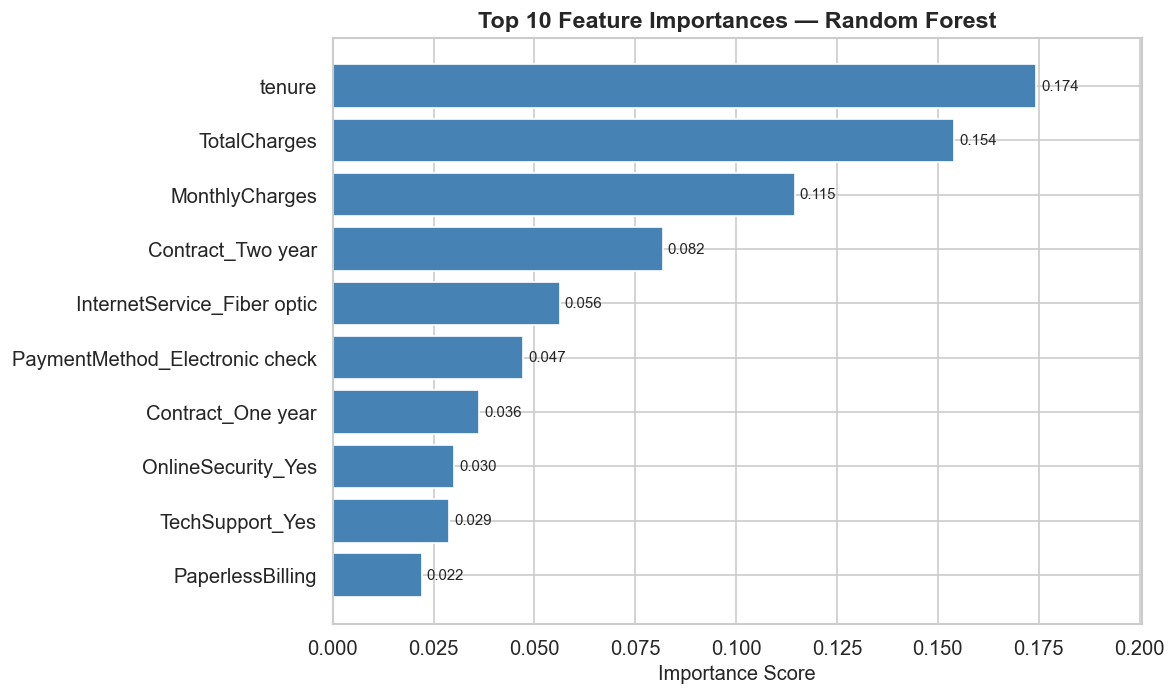

In [22]:
feature_names = X.columns.tolist()

plot_feature_importance(
    rf_model,
    feature_names=feature_names,
    top_n=10,
    save_path=f"{FIGURES_DIR}/09_feature_importance.png",
)

---
## 9. Business Insights & Recommendations

Based on the exploratory analysis and model results, the following **actionable findings** are surfaced for telecom decision-makers:

---

### Finding 1 — Month-to-Month Contracts Are the Biggest Risk Flag
Customers on month-to-month contracts churn at roughly **3–4×** the rate of those on one- or two-year contracts. **Recommendation:** Offer time-limited incentives (e.g., discounted first year, locked-in rate guarantee) to migrate at-risk month-to-month customers to annual plans.

---

### Finding 2 — Fibre Optic Internet Customers Leave More Frequently
Despite (or perhaps because of) the premium service tier, Fibre Optic subscribers show a significantly higher churn rate than DSL customers. This suggests a **value-for-money dissatisfaction** signal. **Recommendation:** Conduct NPS surveys targeting Fibre Optic users, review pricing tiers, and proactively reach out to new Fibre customers within the first 90 days.

---

### Finding 3 — New Customers (Low Tenure) Are the Most Vulnerable
The churn histogram clearly shows a spike in the first 1–6 months of tenure. **Recommendation:** Invest in a structured onboarding programme with check-in calls, tutorial resources, and a dedicated support pathway in the first 6 months — the period with the highest churn risk.

---

### Finding 4 — Higher Monthly Charges Predict Churn
Churned customers pay meaningfully higher monthly charges on average. This indicates **price sensitivity** at the higher end of the billing spectrum. **Recommendation:** Introduce loyalty discounts or service bundles for customers whose monthly bill exceeds a defined threshold (e.g., USD 70/month).

---

### Finding 5 — Deploy the Predictive Model as an Early-Warning System
The Random Forest model achieves strong recall on churners, meaning it can **identify at-risk customers before they leave**. **Recommendation:** Integrate this model into the CRM system to generate a weekly churn-risk score per customer. Customer success teams can then prioritise outreach for the top-decile risk segment, focusing retention spend where it matters most.

In [23]:
# ── Final summary printout ────────────────────────────────────────────────────
print("="*60)
print("  PROJECT COMPLETE — Summary")
print("="*60)
print(f"  Dataset     : IBM Telco Customer Churn")
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Features    : {X.shape[1]}")
print(f"  Churn rate  : {y.mean():.2%}")
print()
print(f"  --- Logistic Regression ---")
print(f"  Accuracy  : {lr_metrics['accuracy']:.4f}")
print(f"  F1 Score  : {lr_metrics['f1']:.4f}")
print()
print(f"  --- Random Forest ---")
print(f"  Accuracy  : {rf_metrics['accuracy']:.4f}")
print(f"  F1 Score  : {rf_metrics['f1']:.4f}")
print()
print(f"  Figures saved to: {FIGURES_DIR}/")
print("="*60)

  PROJECT COMPLETE — Summary
  Dataset     : IBM Telco Customer Churn
  Rows        : 7,043
  Features    : 30
  Churn rate  : 26.54%

  --- Logistic Regression ---
  Accuracy  : 0.7388
  F1 Score  : 0.6143

  --- Random Forest ---
  Accuracy  : 0.7722
  F1 Score  : 0.6128

  Figures saved to: ../outputs/figures/
